In [6]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def to_hwc(img):
    img = np.array(img)

    # case 1: CHW
    if img.ndim == 3 and img.shape[0] in [1, 3, 4]:
        img = np.transpose(img, (1, 2, 0))

    # case 2: grayscale (H, W)
    if img.ndim == 2:
        img = np.stack([img]*3, axis=-1)

    # case 3: 잘못된 경우 (채널 이상)
    if img.ndim == 3 and img.shape[2] not in [1, 3, 4]:
        img = img[:, :, :3]  # 강제로 3채널

    return img

def load_images(hdf5_path, demo_key="demo_0", cam_key="agentview_image"):
    f = h5py.File(hdf5_path, "r")
    imgs = f[f"data/{demo_key}/obs/{cam_key}"][()]
    f.close()
    return imgs

def show_side_by_side(imgs1, imgs2, num_frames=10):
    idxs = np.linspace(0, len(imgs1)-1, num_frames).astype(int)

    for i in idxs:
        fig, axs = plt.subplots(1, 2, figsize=(6, 3))

        img1 = to_hwc(imgs1[i])
        img2 = to_hwc(imgs2[i])

        axs[0].imshow(img1)
        axs[0].set_title("no aug")
        axs[0].axis("off")

        axs[1].imshow(img2)
        axs[1].set_title("aug")
        axs[1].axis("off")

        plt.show()

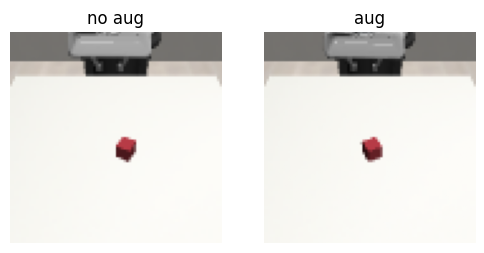

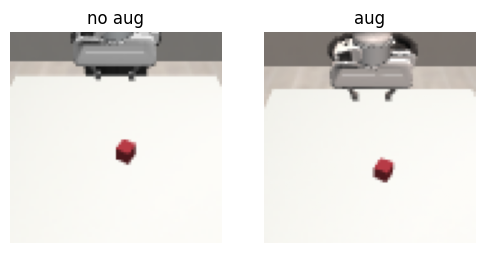

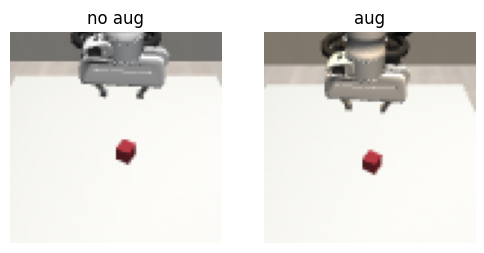

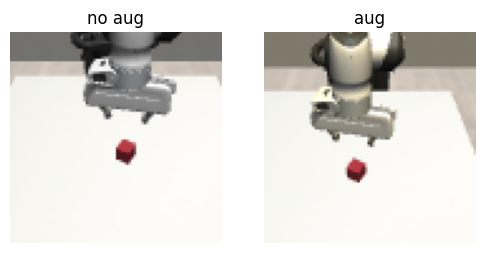

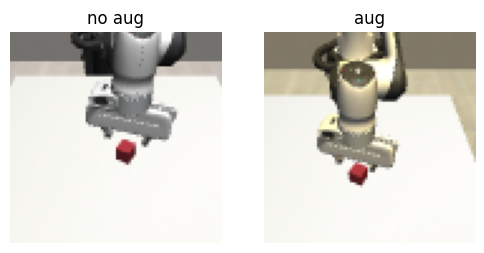

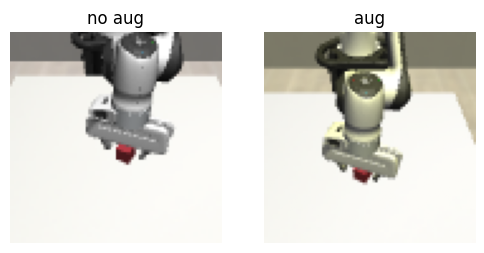

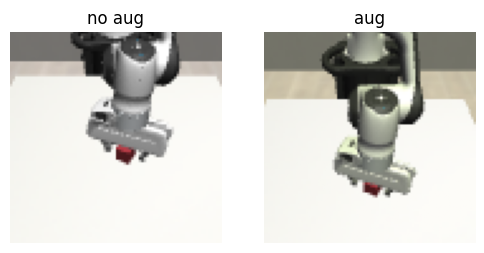

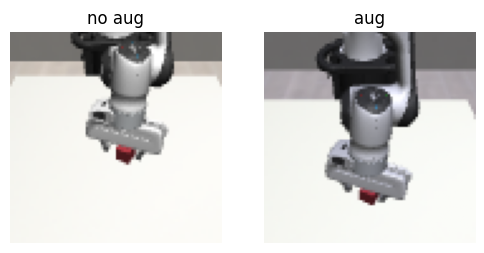

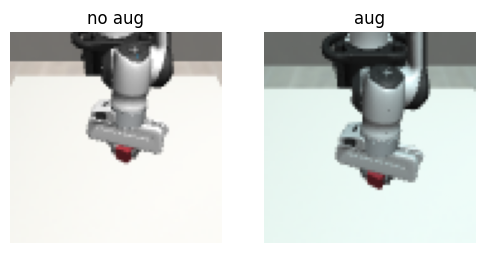

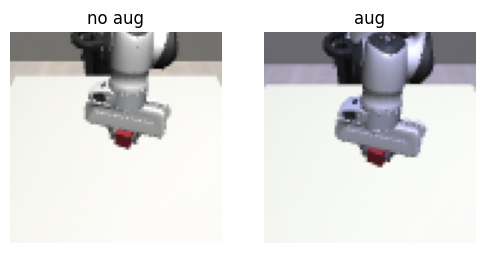

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (84, 84) to (96, 96) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[swscaler @ 0x441f7400] Warning: data is not aligned! This can lead to a speed loss
Lossy conversion from float32 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (84, 84) to (96, 96) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
Lossy conversion from float32 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range 

In [7]:
imgs_noaug = load_images("data/lift_ph.hdf5")
imgs_aug = load_images("data/lift_aug_ph.hdf5")

show_side_by_side(imgs_noaug, imgs_aug)

import imageio

def save_video(imgs, path, fps=20):
    imageio.mimsave(path, imgs, fps=fps)

save_video(imgs_noaug, "noaug.mp4")
save_video(imgs_aug, "aug.mp4")